In [2]:
import os 

os.chdir("/Users/seungyeon/workspace/chord_recog/code/scripts")

In [2]:
from extractor.audio_extractor import AudioExtractor 
from extractor.feature_extractor import FeatureExtractor


# TEST_URL = "https://youtu.be/xKT92YmzhJw"
# TEST_URL = "https://youtu.be/T4lJNIH-iAg"
extractor = FeatureExtractor()
# audio_file = AudioExtractor().execute(TEST_URL)
# audio_file = "/Users/seungyeon/workspace/chord_recog/code/scripts/Crush (크러쉬) - 'UP ALL NITE (Feat. SUMIN)' MV.wav"
audio_file = "/Users/seungyeon/workspace/chord_recog/code/scripts/Crush, Han Sang Won - SKIP [AUDIO⧸MP3].wav"
# if audio_file is not None:
#     beats, beats_t, cqt, chroma = FeatureExtractor().execute(str(audio_file))
#     os.remove(audio_file)

In [9]:
import librosa

sr = 22050
hop_length = 512 

y, _ = librosa.load(audio_file, sr=sr)
y_harmonic, y_percussive = librosa.effects.hpss(y, margin=2.0)
y_bass_only = extractor.apply_lowpass_filter(y_harmonic, sr=sr, cutoff_freq=120)

In [6]:
import numpy as np

fmin = librosa.note_to_hz("C1")
hop_length = 512
n_bins = 36

C = np.abs(
    librosa.cqt(
        y_harmonic,
        sr=sr,
        hop_length=hop_length,
        fmin=fmin,
        n_bins=n_bins,
        bins_per_octave=12,
    )
)  # Shape: (36, N_frames)
chroma = librosa.feature.chroma_cqt(
    y=y_bass_only, sr=sr, hop_length=hop_length
)

In [10]:
import soundfile 

soundfile.write("/Users/seungyeon/workspace/chord_recog/code/scripts/bass_test.wav", y_bass_only, 22050)

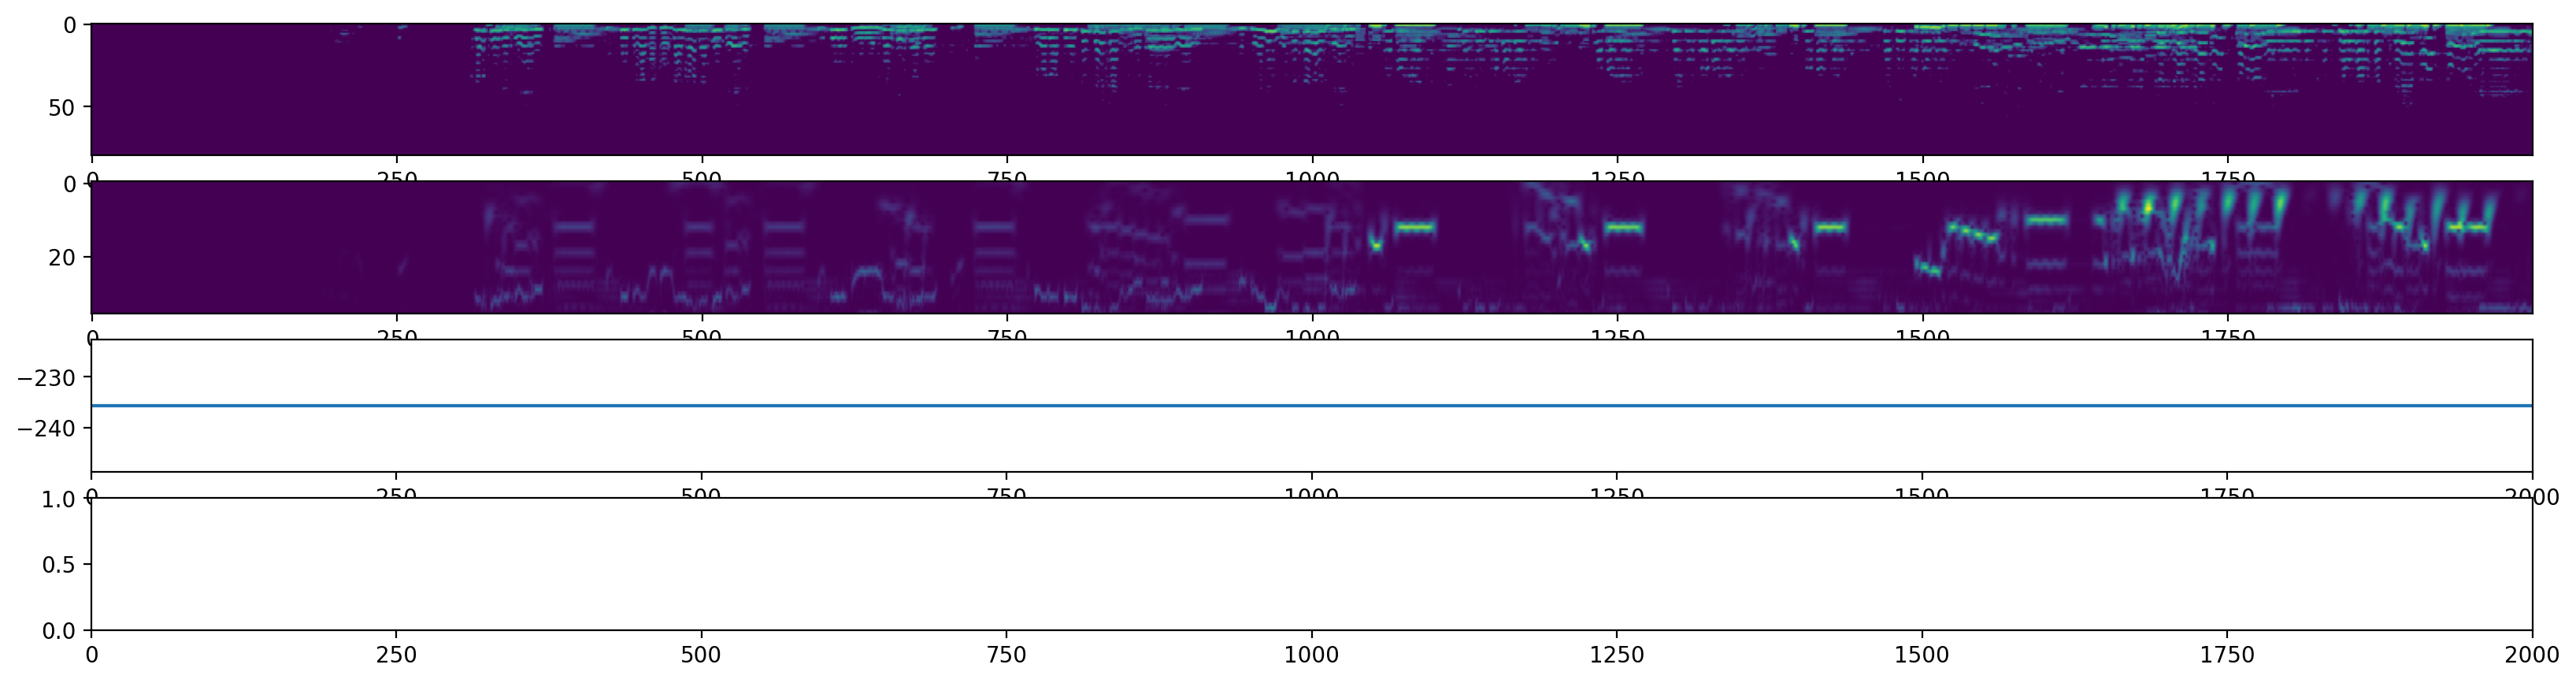

In [7]:
import matplotlib.pyplot as plt 


mel = librosa.feature.melspectrogram(y=y_harmonic, sr=sr, n_mels=80) 
mel = librosa.amplitude_to_db(mel)
onsets_ = [o for o in onsets if o < 2000]

plt.figure(figsize=(20, 5))
plt.subplot(411)
plt.imshow(mel[:, :2000], aspect='auto')
# plt.vlines(onsets_, ymin=-0.5, ymax=19.5, colors="r")
plt.subplot(412)
plt.imshow(C[:, :2000], aspect='auto')
# plt.vlines(onsets_, ymin=-0.5, ymax=11.5, colors="r")
plt.subplot(413)
# plt.imshow(np.pad(chroma_diff[:, :2000], 0), aspect='auto')
plt.plot(range(2000), bass_pitch[:2000])
# plt.vlines(onsets_, ymin=0, ymax=1, colors="r")
plt.xlim([0, 2000])
plt.subplot(414)
# plt.plot(range(2000), o_env_bass[:2000])
# plt.vlines(onsets_, ymin=0, ymax=1, colors="r")
plt.xlim([0, 2000])
plt.show()

In [3]:
import librosa 


sr = 22050
hop_len = 512 

if audio_file is not None:
    y, _ = librosa.load(audio_file, sr=sr)
    beats_t = extractor.extract_beat(audio_file, len(y))

In [4]:
# 2. HPSS 적용 (화성 성분과 타격 성분 분리)
# margin 파라미터(기본값 1.0)를 높이면 화성을 더 엄격하게 분리하지만 음원 손실이 생길 수 있음
y_harmonic, y_percussive = librosa.effects.hpss(y, margin=2.0)
# 3. 타격음이 제거된 화성 오디오(y_harmonic)로 CQT 크로마그램 추출
# (이전 논의대로 magnitude -> L2 정규화만 수행)
# chroma = librosa.feature.chroma_cqt(
#     y=y_harmonic, sr=sr, hop_length=hop_len
# )
y_filtered = extractor.apply_lowpass_filter(y_harmonic, sr=sr)
bass_pitch_, bass_frames = extractor.extract_beat_synchronous_bass(y_filtered, beats_t, sr=sr, hop_length=hop_len)

# chroma_beat = extractor.beat_based_pooling(chroma, beats)
# bass_chroma_beat = extractor.beat_based_pooling(bass, beats)
# bass_pitch_beat = extractor.beat_based_pooling(bass_pitch, beats)

In [5]:
if audio_file is not None:
    beats, bass_pitch, chroma = extractor.execute(audio_file)

📊 오디오 특징(Chroma & Beat) 분석 중...


In [6]:
import numpy as np

np.array_equal(bass_pitch_, bass_pitch)

True

In [ ]:
from chord.constants import IDX_TO_PITCH_CLASS
from pretty_midi import PrettyMIDI, Note, Instrument


label = []
obj = PrettyMIDI()
obj.instruments.append(Instrument(0))
notes = []
for (start, end), b in zip(bass_frames, bass_pitch):
    notes.append(Note(velocity=70, pitch=int(b), start=start, end=end))
obj.instruments[0].notes = notes 

obj.write("bass_test.mid")
    

In [7]:
with open("bass_test.lab", "w") as f:
    f.writelines(label)

In [5]:
import numpy as np

from chord.converter import extract_sequences_from_choco, compute_chord_transition_matrix_numpy, export_debug_pivot_table


sequences = extract_sequences_from_choco(
    "/Users/seungyeon/workspace/chord_recog/data/choco/jams"
)
prob_matrix = compute_chord_transition_matrix_numpy(sequences)
np.save(
    "/Users/seungyeon/workspace/chord_recog/code/scripts/chord/transition_matrix.npy",
    prob_matrix,
    allow_pickle=True,
)
# count_matrix = compute_chord_transition_matrix_numpy(sequences, return_count=True)
# export_debug_pivot_table(count_matrix)